<a href="https://colab.research.google.com/github/justamy20/scikit-learn-Cookbook/blob/main/11%20Bab%2011%3A%20Novelty%20and%20Outlier%20Detection/Chapter_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11: Novelty and Outlier Detection

<div class="alert alert-info">
<b>Chapter Overview:</b> In this chapter, we explore algorithms designed to identify anomalies within datasets. We will dissect the fundamental differences between <b>Outlier Detection</b> (unsupervised learning on polluted data) and <b>Novelty Detection</b> (semi-supervised learning identifying anomalies in new, unseen data).
</div>

## 1. Outlier vs Novelty Detection
**Theoretical Deep-Dive:**
While often used interchangeably, scikit-learn makes a strict distinction between these two anomaly detection tasks based on the condition of the training data:

1. **Outlier Detection:** The training data is assumed to *already contain* outliers. The algorithms (like Isolation Forest or Local Outlier Factor) try to fit the regions where the training data is most concentrated, ignoring the deviant observations.
2. **Novelty Detection:** The training data is assumed to be *100% clean* (no outliers). The algorithm (like One-Class SVM) learns the boundary of this normal data. When new data arrives, the model evaluates whether it falls inside the learned boundary (normal) or outside (novelty).

**Important scikit-learn Convention:** For all anomaly detection estimators, the `predict()` method returns `1` for normal data (inliers) and `-1` for anomalies (outliers).

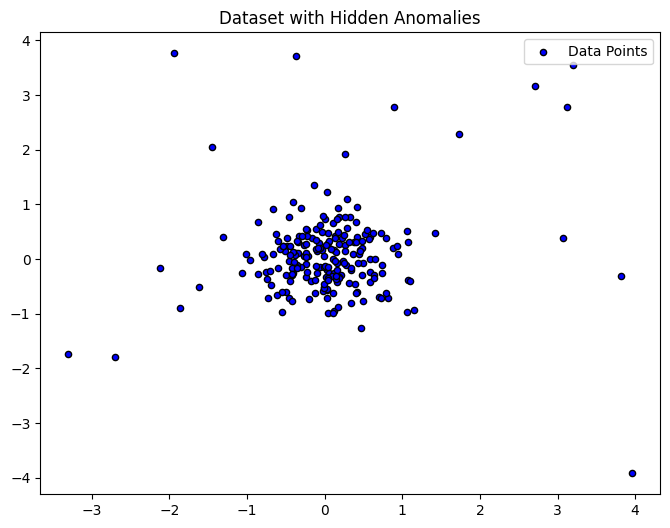

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Set up a generic dataset with normal points and a few obvious outliers
X_inliers, _ = make_blobs(centers=[[0, 0], [0, 0]], cluster_std=0.5, random_state=42, n_samples=200)
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2)) # 20 random extreme points

X = np.vstack([X_inliers, X_outliers])

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], color='blue', s=20, edgecolor='k', label='Data Points')
plt.title("Dataset with Hidden Anomalies")
plt.legend()
plt.show()

---
## 2. Isolation Forest (Outlier Detection)
**Theoretical Deep-Dive:**
Unlike traditional methods that profile "normal" data to find deviations, the **Isolation Forest** explicitly isolates anomalies. It builds an ensemble of Random Trees. At each node, it randomly selects a feature and a random split value.



The core logic is elegant: **Outliers are easier to isolate**. Because outliers are few and far from normal data, they get isolated into a leaf node very quickly (near the root of the tree). Normal points, being densely packed, require many more splits to be isolated.

The anomaly score $s(x, n)$ for an observation $x$ is calculated based on its expected path length $E(h(x))$ across all trees:
$$s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$$
Where $c(n)$ is the average path length of unsuccessful searches in a Binary Search Tree. If $s \approx 1$, the point is an anomaly.

In [ ]:
from sklearn.ensemble import IsolationForest

# contamination sets the expected proportion of outliers (we added 20 outliers to 200 inliers ~ 9%)
iso_forest = IsolationForest(contamination=0.09, random_state=42)
y_pred_iso = iso_forest.fit_predict(X)

# Visualizing Isolation Forest Results
plt.figure(figsize=(8, 6))
plt.scatter(X[y_pred_iso == 1][:, 0], X[y_pred_iso == 1][:, 1], c='blue', s=20, edgecolor='k', label='Inliers')
plt.scatter(X[y_pred_iso == -1][:, 0], X[y_pred_iso == -1][:, 1], c='red', s=50, marker='X', label='Outliers (-1)')
plt.title("Outlier Detection using Isolation Forest")
plt.legend()
plt.show()

---
## 3. Local Outlier Factor / LOF (Outlier Detection)
**Theoretical Deep-Dive:**
**LOF** is a density-based algorithm. Instead of looking at global distances, it measures the *local deviation* of density of a given sample with respect to its nearest neighbors.

It calculates the Local Reachability Density (LRD) of a point and compares it to the LRD of its $k$ nearest neighbors. The LOF score is the ratio:
$$LOF_k(A) = \frac{\sum_{B \in N_k(A)} \frac{lrd_k(B)}{lrd_k(A)}}{|N_k(A)|}$$

- $LOF \approx 1$: The point has a similar density to its neighbors (Inlier).
- $LOF \gg 1$: The point has a substantially lower density than its neighbors (Outlier).

This makes LOF incredibly powerful for datasets where clusters have different densities. An anomaly near a dense cluster might be closer in absolute distance than a normal point in a sparse cluster, but LOF will correctly identify it based on *relative* local density.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# LOF has no 'predict' method for outlier detection after fitting, it uses fit_predict
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.09)
y_pred_lof = lof.fit_predict(X)

# Extract negative outlier factors (the lower the score, the more abnormal the point)
X_scores = lof.negative_outlier_factor_

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], color='k', s=3.0, label='Data points')
# Plot circles with radius proportional to the outlier scores
radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())
plt.scatter(X[:, 0], X[:, 1], s=1000 * radius, edgecolors='r', facecolors='none', label='Outlier score')
plt.title("Local Outlier Factor (LOF)")
plt.legend()
plt.show()

---
## 4. One-Class SVM (Novelty Detection)
**Theoretical Deep-Dive:**
**One-Class Support Vector Machine (OCSVM)** is the premier algorithm for *Novelty Detection*. We train it **exclusively** on the normal data. It uses the "Kernel Trick" (usually RBF) to project the data into a high-dimensional space and finds the maximum-margin hyperplane that separates the normal data from the origin.



The objective function involves the parameter $\nu$ (nu), which sets an upper bound on the fraction of training errors (false positives) and a lower bound of the fraction of support vectors:
$$\min_{w, \rho} \frac{1}{2} ||w||^2 - \rho + \frac{1}{\nu N} \sum_{i=1}^N \xi_i$$
When a new data point is introduced, the OCSVM evaluates which side of the hyperplane the point lands on. If it's outside the enclosed "normal" volume, it's flagged as a novelty.

In [ ]:
from sklearn.svm import OneClassSVM

# For Novelty Detection, we ONLY train on the clean inliers
ocsvm = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
ocsvm.fit(X_inliers) # Notice we fit on X_inliers only!

# We now predict on the entire dataset (which includes the new hidden outliers)
y_pred_ocsvm = ocsvm.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[y_pred_ocsvm == 1][:, 0], X[y_pred_ocsvm == 1][:, 1], c='blue', s=20, edgecolor='k', label='Predicted Normal')
plt.scatter(X[y_pred_ocsvm == -1][:, 0], X[y_pred_ocsvm == -1][:, 1], c='red', s=50, marker='X', label='Detected Novelty')

# Draw the decision boundary contour
xx, yy = np.meshgrid(np.linspace(-5, 5, 50), np.linspace(-5, 5, 50))
Z = ocsvm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='green')

plt.title("Novelty Detection with One-Class SVM")
plt.legend()
plt.show()

---
### Chapter 11 Summary
*(Fulfilling Assignment Requirement 3.b: Summarize each chapter)*

In Chapter 11, we explored the critical domain of Anomaly Detection, learning how to identify rare items, events, or observations that raise suspicions by differing significantly from the majority of the data.

**Key Takeaways:**
1. **Context Matters:** We must choose our approach based on the training data. If the training data is already polluted with anomalies, we use **Outlier Detection** algorithms. If we have a pristine dataset of "normal" behavior and want to detect future deviations, we use **Novelty Detection**.
2. **Isolation Forest:** A highly efficient outlier detection algorithm based on Random Forests. It isolates anomalies rather than profiling normal points, leveraging the fact that outliers require fewer splits to be separated. It scales extremely well to high-dimensional datasets.
3. **Local Outlier Factor (LOF):** A density-based outlier detector. It is particularly effective for datasets where clusters possess varying densities, as it identifies anomalies based on their local neighborhood rather than global distances.
4. **One-Class SVM:** The standard approach for novelty detection (semi-supervised). Using the RBF kernel, it creates a tight boundary around the normal training data, classifying anything that falls outside this hyper-sphere as a novelty.

By mastering these techniques, we can build robust data pipelines that automatically filter out sensor errors, detect fraudulent transactions, and maintain model integrity against noisy inputs.